<a href="https://www.kaggle.com/code/sonawanelalitsunil/danish-housing-prices-1992-2024-ml-89-10?scriptVersionId=232351473" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/danish-residential-housing-prices-1992-2024/DKHousingPricesSample100k.csv
/kaggle/input/danish-residential-housing-prices-1992-2024/DKHousingPrices.parquet


### Title: Danish Housing Prices (1992–2024)

#### Description: Trends in residential property prices across Denmark from 1992 to 2024.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/danish-residential-housing-prices-1992-2024/DKHousingPricesSample100k.csv')

In [3]:
df.head()

,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
0,2024-10-24,2024Q4,16,Villa,regular_sale,1997,6500000,-3.0,5,142.0,45774.650,Spættevej 16,2680,Solrød Strand,"Capital, Copenhagen",Zealand,3.1,NaN,NaN
1,2024-10-24,2024Q4,13,Apartment,regular_sale,1885,3400000,0.0,2,46.0,73913.050,"Jakob Dannefærds Vej 10B, 4. th",1973,Frederiksberg C,"Capital, Copenhagen",Zealand,3.1,NaN,NaN
2,2024-10-23,2024Q4,60,Villa,regular_sale,1949,4550000,-4.0,4,112.0,40625.000,Vestre Plantagevej 3,2680,Solrød Strand,"Capital, Copenhagen",Zealand,3.1,NaN,NaN
3,2024-10-23,2024Q4,29,Villa,regular_sale,2001,1630000,-12.0,4,186.0,8763.440,Toftebjerg 3,4400,Kalundborg,Other islands,Zealand,3.1,NaN,NaN
4,2024-10-22,2024Q4,92,Apartment,regular_sale,1965,1975000,-10.0,3,82.0,24085.365,"Ryttergårdsvej 20, 1. 113",3520,Farum,North Zealand,Zealand,3.1,NaN,NaN


In [4]:
df.tail()

,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
99995,1992-01-06,1992Q1,1505832,Villa,family_sale,1970,1122000,0.0,4,150.0,7480.0000,Brudedalen 30,3520,Farum,North Zealand,Zealand,9.5,2.1,10.14
99996,1992-01-06,1992Q1,1505823,Villa,regular_sale,1898,452000,0.0,5,102.0,4431.3726,Bregningevej 1,4593,Eskebjerg,Other islands,Zealand,9.5,2.1,10.14
99997,1992-01-06,1992Q1,1505817,Apartment,regular_sale,1890,1285000,0.0,4,246.0,5223.5770,"Rosengade 15, 1",4200,Slagelse,Other islands,Zealand,9.5,2.1,10.14
99998,1992-01-05,1992Q1,1505868,Villa,family_sale,1954,800000,0.0,6,147.0,5442.1770,Nygårdsvej 112,6700,Esbjerg,South jutland,Jutland,9.5,2.1,10.14
99999,1992-01-05,1992Q1,1505872,Villa,regular_sale,1956,730000,0.0,5,110.0,6636.3640,Grundtvigs Alle 115,6400,Sønderborg,South jutland,Jutland,9.5,2.1,10.14


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   date                                 100000 non-null  object 
 1   quarter                              100000 non-null  object 
 2   house_id                             100000 non-null  int64  
 3   house_type                           100000 non-null  object 
 4   sales_type                           100000 non-null  object 
 5   year_build                           100000 non-null  int64  
 6   purchase_price                       100000 non-null  int64  
 7   %_change_between_offer_and_purchase  100000 non-null  float64
 8   no_rooms                             100000 non-null  int64  
 9   sqm                                  100000 non-null  float64
 10  sqm_price                            100000 non-null  float64
 11  address       

In [6]:
df.describe()

,house_id,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,zip_code,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
count,1.000000e+05,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,99923.000000,99923.000000
mean,7.531364e+05,1955.078530,1.925992e+06,-2.084740,4.375790,129.387820,16406.648074,5951.612680,1.679263,1.927025,4.107445
std,4.348902e+05,45.703585,1.777832e+06,4.852926,1.661686,57.170619,13655.184405,2369.938171,2.048078,1.638440,2.194428
min,1.300000e+01,1000.000000,2.502000e+05,-49.000000,1.000000,26.000000,374.549800,1051.000000,0.000000,0.250000,1.100000
25%,3.770722e+05,1931.000000,8.000000e+05,-3.000000,3.000000,89.000000,6792.940775,4000.000000,0.000000,0.790000,2.120000
50%,7.511035e+05,1966.000000,1.400000e+06,0.000000,4.000000,123.000000,12070.707000,5970.000000,0.750000,1.850000,4.340000
75%,1.128904e+06,1980.000000,2.450000e+06,0.000000,5.000000,160.000000,21343.201500,8250.000000,3.250000,2.340000,5.500000
max,1.507901e+06,2024.000000,4.595500e+07,49.000000,15.000000,984.000000,75000.000000,9990.000000,9.500000,7.700000,10.140000


In [7]:
df.isnull().sum()

date                                    0
quarter                                 0
house_id                                0
house_type                              0
sales_type                              0
year_build                              0
purchase_price                          0
%_change_between_offer_and_purchase     0
no_rooms                                0
sqm                                     0
sqm_price                               0
address                                 0
zip_code                                0
city                                   11
area                                    0
region                                  0
nom_interest_rate%                      0
dk_ann_infl_rate%                      77
yield_on_mortgage_credit_bonds%        77
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(100000, 19)

In [10]:
df.dtypes

date                                    object
quarter                                 object
house_id                                 int64
house_type                              object
sales_type                              object
year_build                               int64
purchase_price                           int64
%_change_between_offer_and_purchase    float64
no_rooms                                 int64
sqm                                    float64
sqm_price                              float64
address                                 object
zip_code                                 int64
city                                    object
area                                    object
region                                  object
nom_interest_rate%                     float64
dk_ann_infl_rate%                      float64
yield_on_mortgage_credit_bonds%        float64
dtype: object

In [11]:
df.columns

Index(['date', 'quarter', 'house_id', 'house_type', 'sales_type', 'year_build',
       'purchase_price', '%_change_between_offer_and_purchase', 'no_rooms',
       'sqm', 'sqm_price', 'address', 'zip_code', 'city', 'area', 'region',
       'nom_interest_rate%', 'dk_ann_infl_rate%',
       'yield_on_mortgage_credit_bonds%'],
      dtype='object')

## Data visualizations

In [12]:
# Convert dates
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['quarter'] = pd.to_datetime(df['quarter'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Drop rows with missing critical values
df = df.dropna(subset=['sqm_price', 'region', 'purchase_price'])

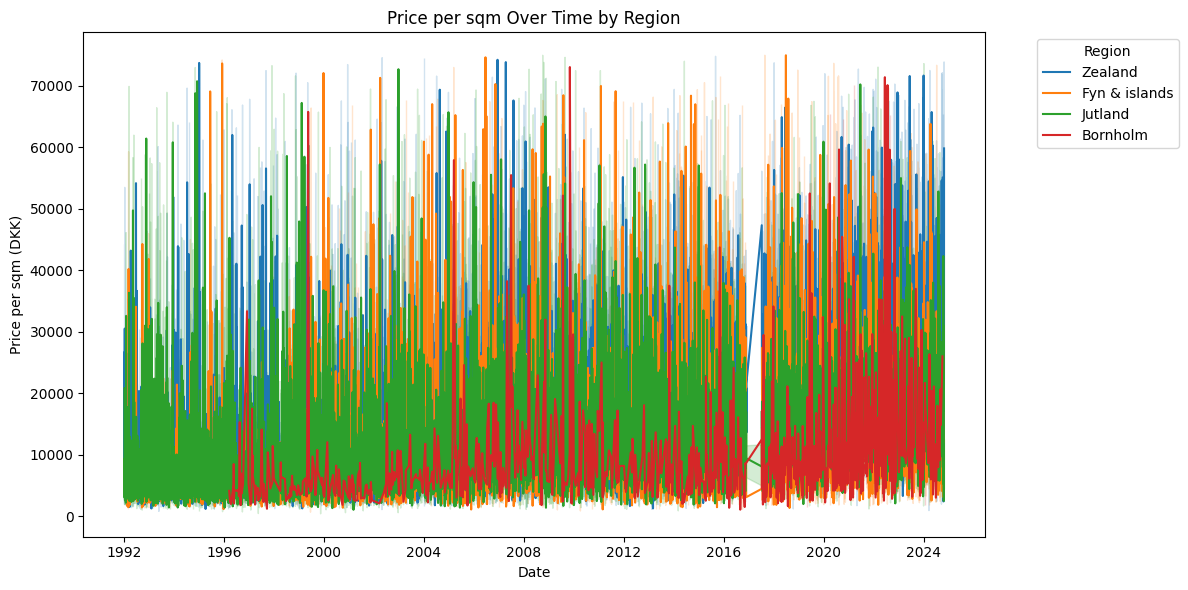

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='sqm_price', hue='region')
plt.title('Price per sqm Over Time by Region')
plt.xlabel('Date')
plt.ylabel('Price per sqm (DKK)')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

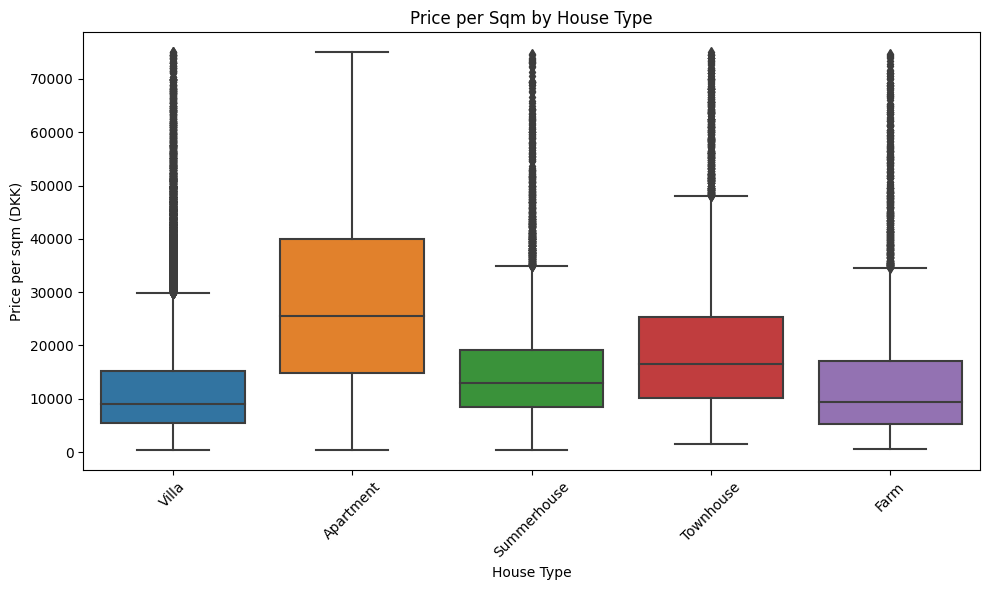

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='house_type', y='sqm_price')
plt.title('Price per Sqm by House Type')
plt.xlabel('House Type')
plt.ylabel('Price per sqm (DKK)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


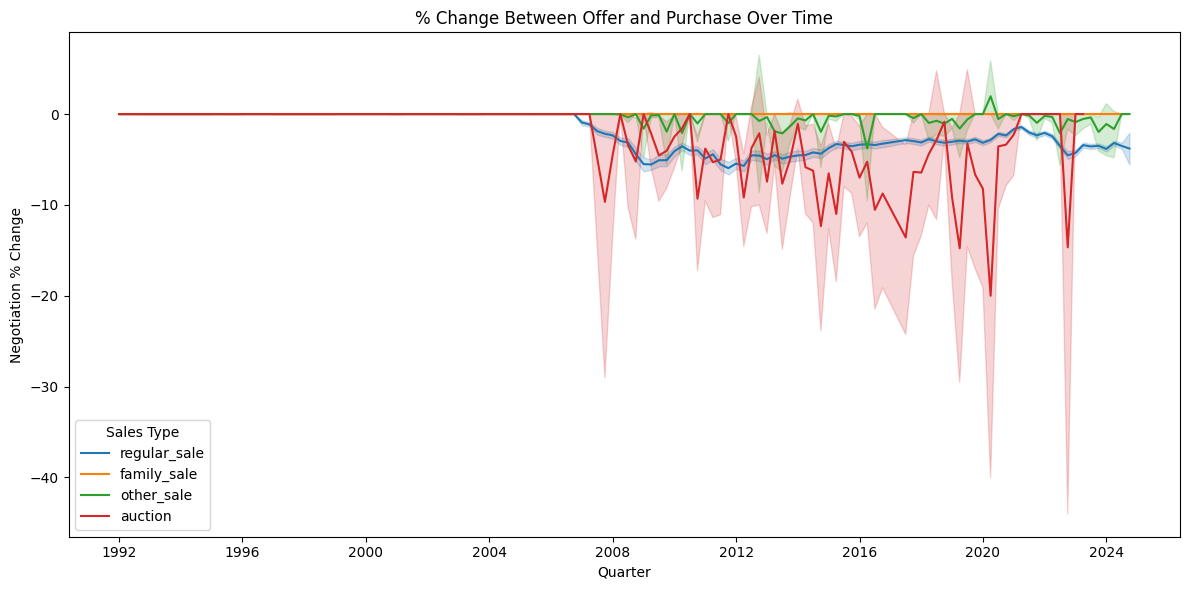

In [15]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='quarter', y='%_change_between_offer_and_purchase', hue='sales_type')
plt.title('% Change Between Offer and Purchase Over Time')
plt.xlabel('Quarter')
plt.ylabel('Negotiation % Change')
plt.legend(title='Sales Type')
plt.tight_layout()
plt.show()


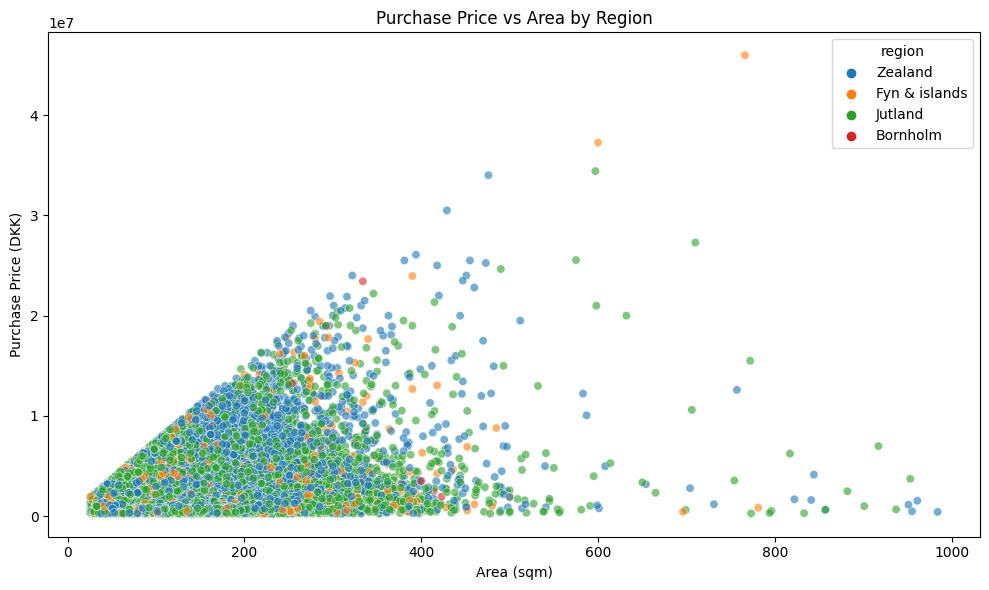

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sqm', y='purchase_price', hue='region', alpha=0.6)
plt.title('Purchase Price vs Area by Region')
plt.xlabel('Area (sqm)')
plt.ylabel('Purchase Price (DKK)')
plt.tight_layout()
plt.show()


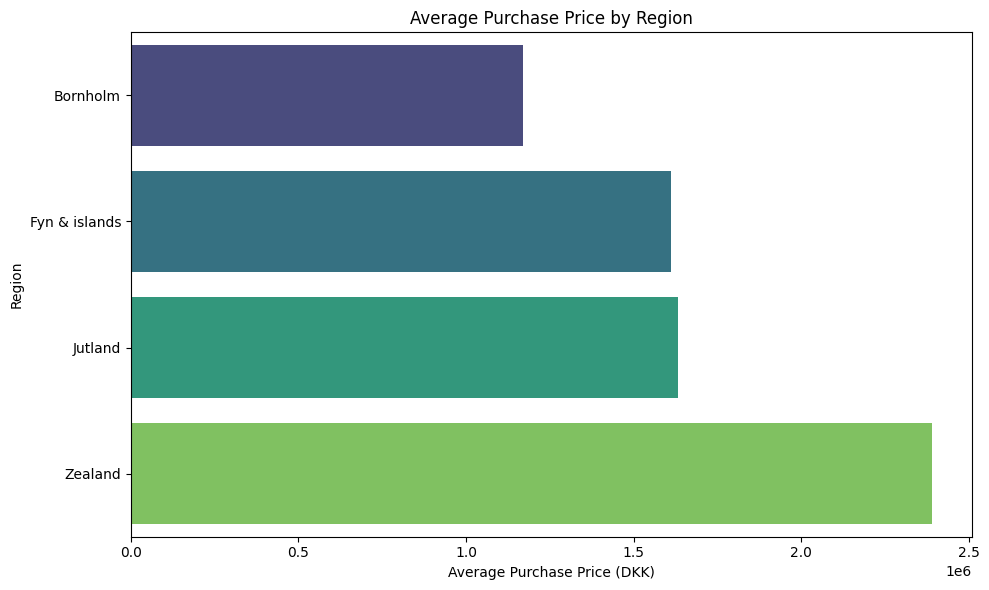

In [17]:
region_avg = df.groupby('region')['purchase_price'].mean().sort_values()
plt.figure(figsize=(10, 6))
sns.barplot(x=region_avg.values, y=region_avg.index, palette='viridis')
plt.title('Average Purchase Price by Region')
plt.xlabel('Average Purchase Price (DKK)')
plt.ylabel('Region')
plt.tight_layout()
plt.show()


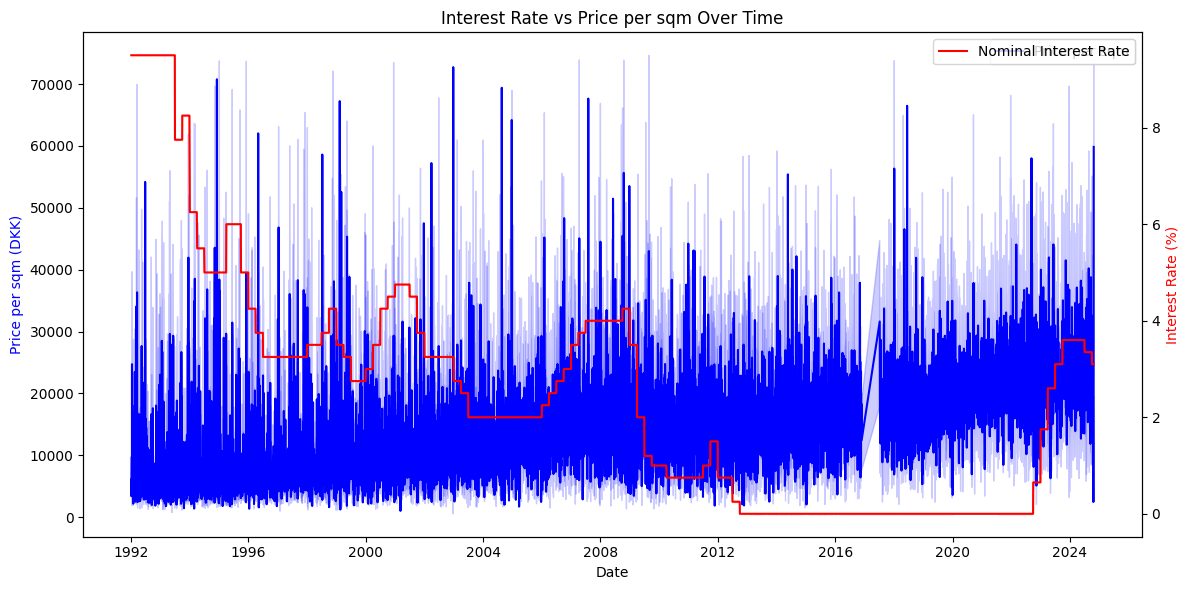

In [18]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax2 = ax1.twinx()
sns.lineplot(data=df, x='date', y='sqm_price', ax=ax1, label='Price per sqm', color='blue')
sns.lineplot(data=df, x='date', y='nom_interest_rate%', ax=ax2, label='Nominal Interest Rate', color='red')

ax1.set_ylabel('Price per sqm (DKK)', color='blue')
ax2.set_ylabel('Interest Rate (%)', color='red')
ax1.set_title('Interest Rate vs Price per sqm Over Time')
ax1.set_xlabel('Date')

fig.tight_layout()
plt.show()


## Predictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [20]:
# Drop non-numeric/text-heavy or ID columns
df.drop(columns=['address', 'house_id', 'zip_code'], inplace=True)


In [21]:
# Drop rows with missing values
df.dropna(inplace=True)

In [22]:
# Convert date/quarter
df['date'] = pd.to_datetime(df['date'])
df['quarter'] = pd.to_datetime(df['quarter'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [23]:
#Drop original date columns
df.drop(columns=['date', 'quarter'], inplace=True)

In [24]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns

# Apply LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [25]:
X = df.drop('sales_type', axis=1)
y = df['sales_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



Model: Logistic Regression
Accuracy: 88.46%


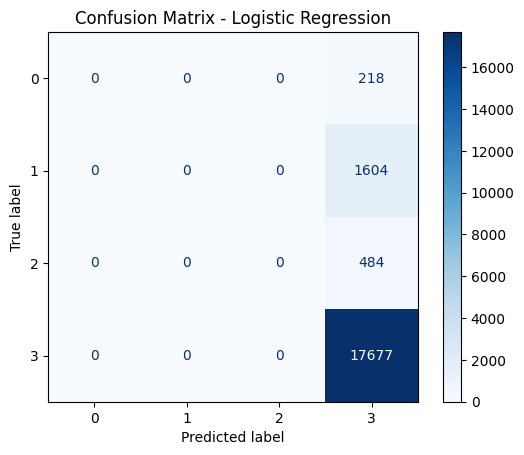


Model: Random Forest
Accuracy: 89.11%


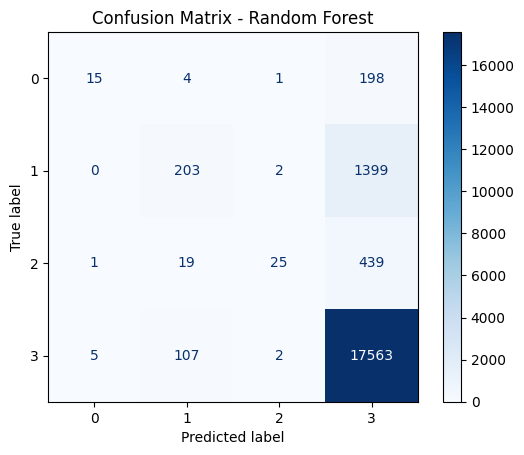


Model: Decision Tree
Accuracy: 82.78%


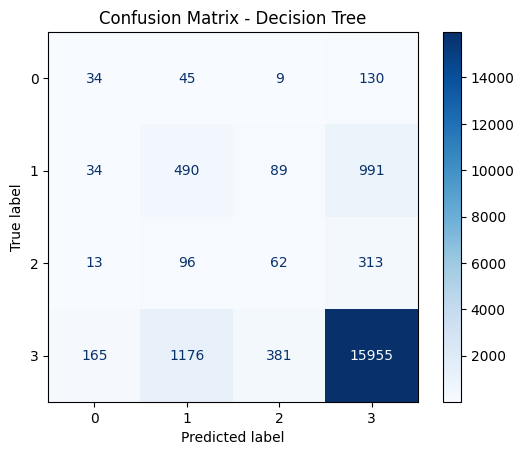


Model: K-Nearest Neighbors
Accuracy: 87.35%


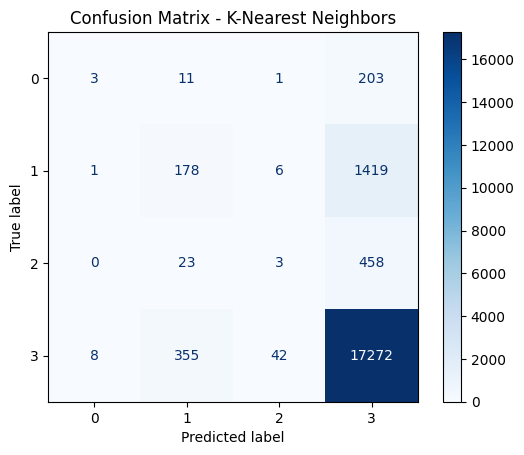


Model: Support Vector Machine
Accuracy: 88.46%


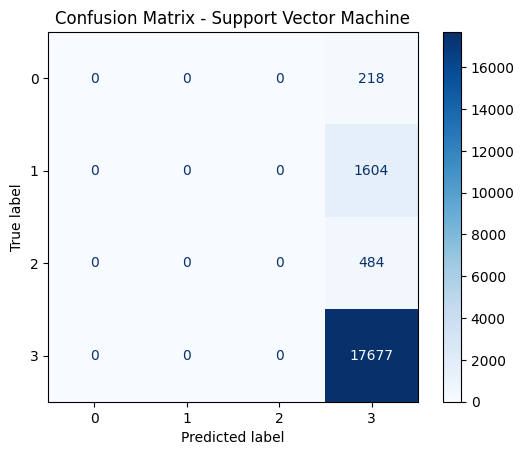

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\nModel: {name}")
    print(f"Accuracy: {acc:.2f}%")
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    
    results.append((name, acc))


In [27]:
# Show accuracies in descending order
results.sort(key=lambda x: x[1], reverse=True)

print("\n🔍 Model Accuracy Comparison:")
for name, acc in results:
    print(f"{name}: {acc:.2f}%")



🔍 Model Accuracy Comparison:
Random Forest: 89.11%
Logistic Regression: 88.46%
Support Vector Machine: 88.46%
K-Nearest Neighbors: 87.35%
Decision Tree: 82.78%


## Thank you...pls upvote!!!